## NDVI Smoothing

### Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

### Load Files

In [7]:
#Original Yanamarey
YImp = '/Users/williamhirsh/Documents/School - Research/GlacierProject/RawData/NDVI/Y_ImpNDVI_Raw.csv'
YNon = '/Users/williamhirsh/Documents/School - Research/GlacierProject/RawData/NDVI/Y_NonNDVI_Raw.csv'

#Updated RB (2025)
RImp = '/Users/williamhirsh/Documents/School - Research/GlacierProject/RawData/NDVI/RB_ImpNDVI_Raw.csv'
RNon = '/Users/williamhirsh/Documents/School - Research/GlacierProject/RawData/NDVI/RB_NonNDVI_Raw.csv'

#New RB (Feb 2026)
RImpFeb = '/Users/williamhirsh/Documents/School - Research/GlacierProject/RawData/NDVI/RB_IMP_NDVI_FEB.csv'
RNonFeb = '/Users/williamhirsh/Documents/School - Research/GlacierProject/RawData/NDVI/RB_NON_NDVI_FEB.csv'

#Median RB
RImpMed = '/Users/williamhirsh/Documents/School - Research/GlacierProject/RawData/NDVI/RB_FEB_IMP_Median.csv'
RNonMed = '/Users/williamhirsh/Documents/School - Research/GlacierProject/RawData/NDVI/RB_FEB_NON_Median.csv'

#Median Yanamarey

Test = '/Users/williamhirsh/Documents/School - Research/GlacierProject/RawData/NDVI/ndvi_test.csv'

#Change filepath to one of the above paths
file_path = RNonMed

### Smoothing

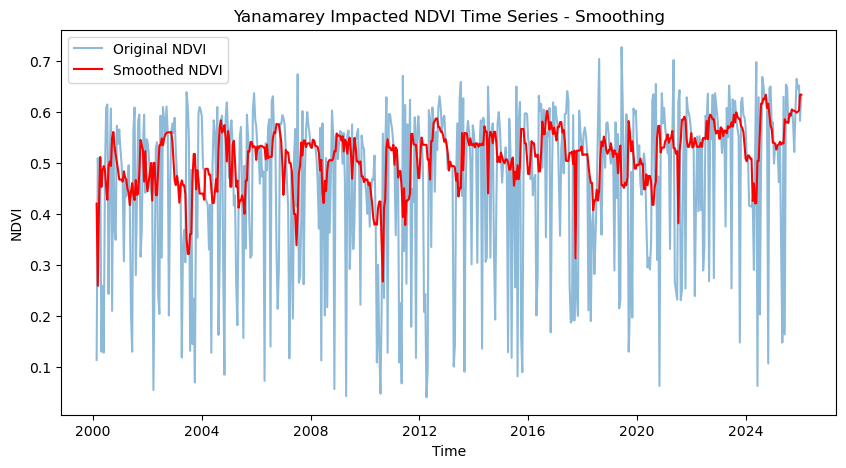

In [8]:
df = pd.read_csv(file_path)

def iammf_smoothing(df, n=2, max_window=30):                                     #adjust n (minimum surrounding values) and max window, default 2, 30
    df = df.sort_values(by='time').reset_index(drop=True)
    df['NDVI_smoothed'] = df['NDVI'].copy()

    for i in range(len(df)):
        window_size = 6  # Start with a 3-day window                             #adjust initialwindow size here, default 3
        valid_values = []

        while window_size <= max_window:
            left_window = df.iloc[max(0, i - window_size):i]['NDVI'].dropna().tolist()
            right_window = df.iloc[i+1:min(len(df), i + window_size + 1)]['NDVI'].dropna().tolist()

            if len(left_window) + len(right_window) >= n:
                valid_values = left_window + right_window
                median = np.median(valid_values)
                mad = np.median(np.abs(valid_values - median))

                if len(valid_values) >= n + 1:
                    prev_median = df.loc[i, 'NDVI_smoothed']
                    if abs(median - prev_median) < 0.5 * mad:                    #adjust MAD threshold here, default 0.5
                        break  # Converged

                df.at[i, 'NDVI_smoothed'] = median

            window_size += 1  # Expand window

    return df

# Apply smoothing
df_smoothed = iammf_smoothing(df)

# Plot original vs. smoothed NDVI
df_smoothed['time'] = pd.to_datetime(df_smoothed['time'])
plt.figure(figsize=(10, 5))
plt.plot(df_smoothed['time'], df_smoothed['NDVI'], label='Original NDVI', alpha=0.5)
plt.plot(df_smoothed['time'], df_smoothed['NDVI_smoothed'], label='Smoothed NDVI', color='red')
plt.xlabel('Time')
plt.ylabel('NDVI')
plt.legend()
plt.title('Yanamarey Impacted NDVI Time Series - Smoothing')
plt.show()

### Export

In [9]:
YanamareyImpNSmooth = '/Users/williamhirsh/Documents/School - Research/GlacierProject/Intermediate/NDVI/YanImpNSmooth.csv'
YanamareyNonNSmooth = '/Users/williamhirsh/Documents/School - Research/GlacierProject/Intermediate/NDVI/YanNonNSmooth.csv'
RitacubaImpNSmooth = '/Users/williamhirsh/Documents/School - Research/GlacierProject/Intermediate/NDVI/RBImpNSmooth.csv'
RitacubaNonNSmooth ='/Users/williamhirsh/Documents/School - Research/GlacierProject/Intermediate/NDVI/RBNonNSmooth.csv'
TestSmooth = '/Users/williamhirsh/Documents/School - Research/GlacierProject/Intermediate/NDVI/ndiv_test_smooth.csv'

#Median
RImpMedSmooth = '/Users/williamhirsh/Documents/School - Research/GlacierProject/Intermediate/NDVI/RImpMedSmooth.csv'
RNonMedSmooth = '/Users/williamhirsh/Documents/School - Research/GlacierProject/Intermediate/NDVI/RNonMedSmooth.csv'

#Change filepath to one of the above
output_path = RNonMedSmooth

#Export
df_smoothed.to_csv(output_path, index=False)

## Melt Contribution Index

### Imports

In [8]:
import pandas as pd

### Load Files

In [13]:
# CHIRPS Precipitation Data
chirps_yan = '/Users/williamhirsh/Documents/School - Research/GlacierProject/RawData/Climate/Precipitation/chirps_Yan.csv'
chirps_rb = '/Users/williamhirsh/Documents/School - Research/GlacierProject/RawData/Climate/Precipitation/chirps_RB.csv'

# FoG Mass Balance Data
mb_yan = '/Users/williamhirsh/Documents/School - Research/GlacierProject/RawData/MassBalance/MBA_Yanamarey_01.csv'
mb_rb = '/Users/williamhirsh/Documents/School - Research/GlacierProject/RawData/MassBalance/MBA_Ritacuba_01.csv'

#Change filepaths to glacier of interest
chirps_path = chirps_yan
mb_path = mb_yan

#Load as DataFrame
chirps = pd.read_csv(chirps_path)
mb = pd.read_csv(mb_path)



In [18]:
chirps

,date,precip_mm
0,1990-01,70.921
1,1990-02,63.182
2,1990-03,66.136
3,1990-04,207.188
4,1990-05,133.323
...,...,...
414,2024-07,171.782
415,2024-08,138.672
416,2024-09,148.744
417,2024-10,171.818


### Define Parameters

In [14]:
# Areas For Glaciers and Basins (sqkm)
#Yanamarey
AB_imp_yan = 4.17
#Ritacuba Blanco New
AB_imp_rb = 5.43
#Ritacuba Blanco Old
#AB_imp_rb = 15.5


## Set this!!!

AB_imp_set = AB_imp_yan

#Set this

#Water Year Start Month
yan_wy = 10
rb_wy = 1
wy_month = yan_wy

#Start and end years
start_yr = 2000 #2000 for yan, 1990 for rb
end_yr = 2024 # 2024 for both



### MCI Computation

In [15]:
# Define areas for glacier and basins
AB_imp = AB_imp_set # Impacted Basin area in sqkm

# --- LOAD CHIRPS PRECIPITATION DATA ---
# Convert date column to datetime format
chirps["date"] = pd.to_datetime(chirps["date"], format="%Y-%m")
# Extract year and month
chirps["year"] = chirps["date"].dt.year
chirps["month"] = chirps["date"].dt.month
# Rename the precipitation column for consistency
chirps["precipitation"] = chirps["precip_mm"].astype(float)
# Calculate water year: Oct-Sep
chirps["water_year"] = chirps.apply(lambda row: row["year"] + 1 if row["month"] >= wy_month else row["year"], axis=1) 
# Filter for desired range
chirps_filtered = chirps[(chirps["water_year"] >= start_yr) & (chirps["water_year"] <= end_yr)]
# Aggregate to water year totals
water_year_precip = chirps_filtered.groupby("water_year")["precipitation"].sum().reset_index()

# Load Mass Balance data
mass_balance_file = mb
mass_balance_file["Year"] = mass_balance_file["Year"].astype(int)

# Merge the mass balance data with the precipitation data on water year
merged_data = pd.merge(mass_balance_file, water_year_precip, left_on="Year", right_on="water_year")
AG = merged_data["AreaNew"].values  # Glacier area in sqkm (per year)

# Now compute the Mass Balance Metric for each year
# Meltwater depth (M) is provided in the 'MB' column
M = merged_data["MB"].values  # Assuming 'MB' is in mm (water equivalent)

# Precipitation depth (P) is the total precipitation for each water year
P_imp = merged_data["precipitation"].values  # Precipitation for Impacted Basin

# Compute the Mass of Melt (MM) and Mass of Precipitation (MP)
MM_imp = ((P_imp - M) * AG * 1e3)  # kg (mm * km² * 1000)
MP_imp = P_imp * (AB_imp - AG) * 1e3  # kg (mm * km² * 1000)

# Compute the MB Metric for the Impacted Basin
MeltCont = (MM_imp) / ((MM_imp) + MP_imp)  # MB Metric for Imp Basin

# Add the MB Metric to the merged data
merged_data["MeltCont"] = MeltCont

# Export the result with just the MB Metric for the Imp Basin
result = merged_data[["Year", "precipitation", "MeltCont"]]

print(result)

    Year  precipitation  MeltCont
0   2005        748.441  0.284196
1   2006        885.178  0.207692
2   2007        910.039  0.201777
3   2008        909.210  0.074145
4   2009        964.470  0.128016
5   2010        779.041  0.084133
6   2012        868.983  0.139158
7   2013        839.663  0.146732
8   2014        835.733  0.154580
9   2015        785.116  0.103610
10  2016        695.523  0.234297
11  2017        911.592  0.121490
12  2018        974.554  0.078118
13  2019        964.782  0.102819


### Export File

In [16]:
#Save paths
exp_yan = '/Users/williamhirsh/Documents/School - Research/GlacierProject/Intermediate/MCI/yan_MCI.csv'
exp_rb = '/Users/williamhirsh/Documents/School - Research/GlacierProject/Intermediate/MCI/rb_MCI.csv'

#Toggle Export File Path
exportPath = exp_yan

result.to_csv(exportPath, index=False)

## Correlation

### Imports

In [3]:
import numpy as np
import pandas as pd
import scipy.stats as stats
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression 



### Load files

#### Old loading

In [4]:
# #Load NDVI Data
# YanamareyImpNSmooth = '/Users/williamhirsh/Documents/School - Research/GlacierProject/Intermediate/NDVI/YanImpNSmooth.csv'
# YanamareyNonNSmooth = '/Users/williamhirsh/Documents/School - Research/GlacierProject/Intermediate/NDVI/YanNonNSmooth.csv'
# RitacubaImpNSmooth = '/Users/williamhirsh/Documents/School - Research/GlacierProject/Intermediate/NDVI/RBImpNSmooth.csv'
# RitacubaNonNSmooth ='/Users/williamhirsh/Documents/School - Research/GlacierProject/Intermediate/NDVI/RBNonNSmooth.csv'
# TestSmooth = '/Users/williamhirsh/Documents/School - Research/GlacierProject/Intermediate/NDVI/ndiv_test_smooth.csv'

# #Select Study Area
# imp_ndvi = pd.read_csv(RitacubaImpNSmooth)
# non_ndvi = pd.read_csv(RitacubaNonNSmooth)

# #Load chirps precipitation and mb data
# chirps_yan = '/Users/williamhirsh/Documents/School - Research/GlacierProject/RawData/Climate/Precipitation/chirps_Yan.csv'
# chirps_rb = '/Users/williamhirsh/Documents/School - Research/GlacierProject/RawData/Climate/Precipitation/chirps_RB.csv'
# mb_yan = '/Users/williamhirsh/Documents/School - Research/GlacierProject/RawData/MassBalance/MBA_Yanamarey_01.csv'
# mb_rb = '/Users/williamhirsh/Documents/School - Research/GlacierProject/RawData/MassBalance/MBA_Ritacuba_01.csv'

# #Select Study Area
# chirps = pd.read_csv(chirps_rb)
# mb = pd.read_csv(mb_rb)

# #Load in MCI Data
# exp_yan = '/Users/williamhirsh/Documents/School - Research/GlacierProject/Intermediate/MCI/yan_MCI.csv'
# exp_rb = '/Users/williamhirsh/Documents/School - Research/GlacierProject/Intermediate/MCI/rb_MCI.csv'

# #Select Study Area
# mb_metric = pd.read_csv(exp_rb)



#### New Loading

In [4]:
import pandas as pd
from pathlib import Path


# CHANGE ONLY THIS
SITE = "rb"   # "rb" or "yan"


BASE = Path("/Users/williamhirsh/Documents/School - Research/GlacierProject")

# -----------------------
# NDVI paths
# -----------------------
NDVI_PATHS = {
    "yan": {
        "imp": BASE / "Intermediate/NDVI/YanImpNSmooth.csv",
        "non": BASE / "Intermediate/NDVI/YanNonNSmooth.csv",
        #"imp": BASE / "Intermediate/NDVI/RBImpNSmooth.csv",  # replace with median
        #"non": BASE / "Intermediate/NDVI/RBNonNSmooth.csv",
        
    },
    "rb": {
        "imp": BASE / "Intermediate/NDVI/RBImpNSmooth.csv",
        "non": BASE / "Intermediate/NDVI/RBNonNSmooth.csv",
        # "imp": BASE / "Intermediate/NDVI/RImpMedSmooth.csv", # median
        # "non": BASE / "Intermediate/NDVI/RNonMedSmooth.csv",
    }
}

# -----------------------
# CHIRPS + Mass Balance
# -----------------------
CLIMATE_PATHS = {
    "yan": {
        "chirps": BASE / "RawData/Climate/Precipitation/chirps_Yan.csv",
        "mb": BASE / "RawData/MassBalance/MBA_Yanamarey_01.csv",
    },
    "rb": {
        "chirps": BASE / "RawData/Climate/Precipitation/chirps_RB.csv",
        "mb": BASE / "RawData/MassBalance/MBA_Ritacuba_01.csv",
    }
}

# -----------------------
# MCI
# -----------------------
MCI_PATHS = {
    "yan": BASE / "Intermediate/MCI/yan_MCI.csv",
    "rb": BASE / "Intermediate/MCI/rb_MCI.csv",
}


#Load data


imp_ndvi = pd.read_csv(NDVI_PATHS[SITE]["imp"])
non_ndvi = pd.read_csv(NDVI_PATHS[SITE]["non"])

chirps = pd.read_csv(CLIMATE_PATHS[SITE]["chirps"])
mb = pd.read_csv(CLIMATE_PATHS[SITE]["mb"])

mb_metric = pd.read_csv(MCI_PATHS[SITE])


### Parameters

#### Old Manual Params

In [7]:
# # Which Months to Average for analysis? (1-12)
# months_to_average = [1,2,3]

# # Use index to select variable for correlation
# xVarList = ['Precipitation', 'MB', 'MeltCont', 'Temperature',
#             'Precip_Water_Mass', 'Glacier_Melt_Water_Mass', 'Combined_Water_Mass']
# yVarList = ['Non_NDVI_Avg', 'Imp_NDVI_Avg', 'Percent_Change']

# #Index guide:
# # Precip, NonNDVI: 0,0
# # Combined water mass, ImpNDVI: 6,1
# # MeltCont, %Change: 2,2

# #Change here:
# x_var = xVarList[2]
# y_var = yVarList[2]

# #Set water year start month
# yan_wy = 10
# rb_wy = 1
# wy_month = yan_wy #change this 

# #Start and end years
# start_yr = 2000 #2000 for yan, 1990 for rb
# end_yr = 2024 # 2024 for both

# #Impacted basin area
# basin_area_km2 = 4.17 # yan is 4.17 ;rb is 15.5

# #Plot title name
# titleVar = 'Yanamarey NDVI % Change vs Melt Contribution'


#### New Auto Site Config

In [5]:

# SITE CONFIGURATION

SITE = "rb"   # "yan" or "rb"

SITE_CONFIG = {
    "yan": {
        "wy_start": 10,
        "start_yr": 2000,
        "basin_area_km2": 4.17,
        "title_prefix": "Yanamarey"
    },
    "rb": {
        "wy_start": 1,
        "start_yr": 1990,
        "basin_area_km2": 5.43, #different extent of 15.5
        "title_prefix": "Ritacuba Blanco"
    }
}

cfg = SITE_CONFIG[SITE]


# GENERAL PARAMETERS

months_to_average = [1,2,3]

xVarList = [
    'Precipitation', 'MB', 'MeltCont', 'Temperature',
    'Precip_Water_Mass', 'Glacier_Melt_Water_Mass', 'Combined_Water_Mass'
]
yVarList = ['Non_NDVI_Avg', 'Imp_NDVI_Avg', 'Percent_Change']

x_var = xVarList[2]
y_var = yVarList[2]

# #Index guide:
# # Precip, NonNDVI: 0,0
# # Precip, ImpNDVI: 0,1
# # Combined water mass, ImpNDVI: 6,1
# # MeltCont, %Change: 2,2

wy_month = cfg["wy_start"]
start_yr = cfg["start_yr"]
end_yr = 2024
basin_area_km2 = cfg["basin_area_km2"]

titleVar = f'{cfg["title_prefix"]} NDVI % Change vs Melt Contribution'


### Analysis

Pearson Correlation between MeltCont and Percent_Change: 0.28
P-value: 0.3570
R-squared (variance in Percent_Change explained by MeltCont): 0.078
That’s 7.8% of Percent_Change explained by MeltCont


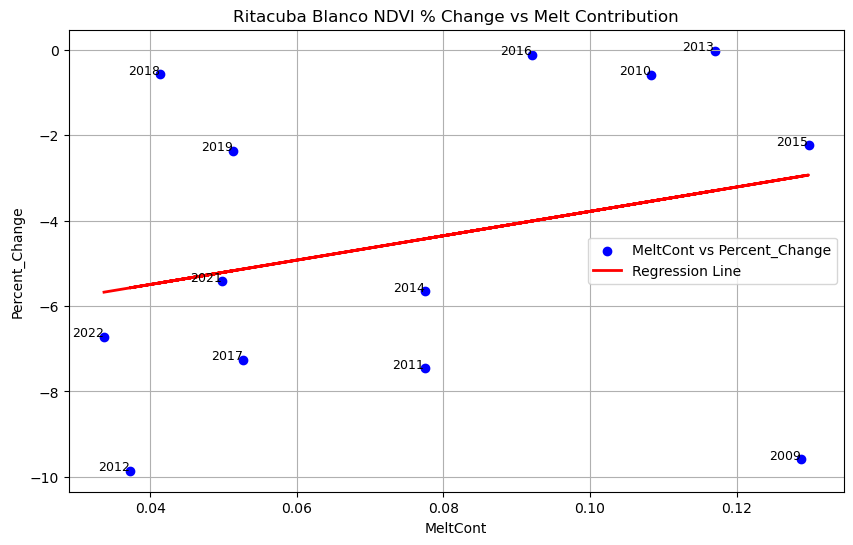

In [6]:
def is_valid_year(row):
    return row["Year"] not in []  # Can adjust this condition as needed

def average_ndvi_by_month(ndvi_data, months):
    ndvi_data['year'] = pd.to_datetime(ndvi_data['time']).dt.year
    ndvi_data['month'] = pd.to_datetime(ndvi_data['time']).dt.month
    return ndvi_data[ndvi_data['month'].isin(months)].groupby('year')['NDVI_smoothed'].mean().reset_index()

# chirps formatting
chirps["date"] = pd.to_datetime(chirps["date"], format="%Y-%m")
chirps["year"] = chirps["date"].dt.year
chirps["month"] = chirps["date"].dt.month
chirps["precipitation"] = chirps["precip_mm"].astype(float)

#water year set
chirps["water_year"] = chirps["year"]
chirps.loc[chirps["month"] >= wy_month, "water_year"] += 1
# For wet months at wet site, should be "0", as wet ndvi should be based on current year

chirps_filtered = chirps[(chirps["water_year"] >= start_yr) & (chirps["water_year"] <= end_yr)]
water_year_precip = chirps_filtered.groupby("water_year")["precipitation"].sum().reset_index()
water_year_precip.rename(columns={'water_year': 'Year', 'precipitation': 'Precipitation'}, inplace=True)

# --- CREATE BASE MERGED DATA ---
merged_data = water_year_precip.copy()

# --- MERGE IN IMPACTED NDVI ---
imp_avg_ndvi = average_ndvi_by_month(imp_ndvi, months_to_average)
merged_data = merged_data.merge(imp_avg_ndvi, how='left', left_on='Year', right_on='year')
merged_data.rename(columns={'NDVI_smoothed': 'Imp_NDVI_Avg'}, inplace=True)

# --- MERGE IN SELECTED NON-IMPACTED NDVI ---
non_avg_ndvi = average_ndvi_by_month(non_ndvi, months_to_average)
merged_data = merged_data.merge(non_avg_ndvi, how='left', left_on='Year', right_on='year')
merged_data.rename(columns={'NDVI_smoothed': 'Non_NDVI_Avg'}, inplace=True)

# --- CALCULATE PERCENT CHANGE ---
merged_data["Percent_Change"] = ((merged_data["Imp_NDVI_Avg"] - merged_data["Non_NDVI_Avg"]) / merged_data["Non_NDVI_Avg"]) * 100

# --- MERGE IN MB DATA ---
mb["Year"] = mb["Year"].astype(int)
merged_data = merged_data.merge(mb, on='Year', how='left')
# Use dynamic glacier area from AreaNew column in MB file
merged_data["Glacier_Area"] = merged_data["AreaNew"]

# merge MB metric file as well
mb_metric["Year"] = mb_metric["Year"].astype(int)
merged_data = merged_data.merge(mb_metric, on='Year', how='left')


# --- DERIVE WATER MASS VARIABLES IN METRIC TONS ---
basin_area_km2 = basin_area_km2
mm_to_t = 1000  # 1 mm over 1 km² = 1000 metric tons
mm_to_t = 1e3  # mm * km² * 1000 = kg

# Recalculate Glacier Melt Water Mass equation: MM_imp = (P - M) * AG * 1e3
merged_data["Glacier_Melt_Water_Mass"] = (merged_data["Precipitation"] - merged_data["MB"]) * merged_data["Glacier_Area"] * mm_to_t

# Recalculate Precipitation Water Mass equation: MP_imp = P * (AB - AG) * 1e3
merged_data["Precip_Water_Mass"] = merged_data["Precipitation"] * (basin_area_km2 - merged_data["Glacier_Area"]) * mm_to_t

# Combined Water Mass remains the same
merged_data["Combined_Water_Mass"] = merged_data["Precip_Water_Mass"] + merged_data["Glacier_Melt_Water_Mass"]

# Melt Contribution Metric
merged_data["MeltCont"] = merged_data["Glacier_Melt_Water_Mass"] / merged_data["Combined_Water_Mass"]


# --- FILTERING ---
merged_data['Year'] = merged_data['Year'].astype(str)
merged_data_filtered = merged_data[merged_data.apply(is_valid_year, axis=1)]

# --- CORRELATION ANALYSIS ---
corr_df = merged_data_filtered[[x_var, y_var]].dropna()
corr, p_value = stats.pearsonr(corr_df[x_var], corr_df[y_var])
print(f"Pearson Correlation between {x_var} and {y_var}: {corr:.2f}")
print(f"P-value: {p_value:.4f}")

# --- REGRESSION AND PLOTTING ---
X = corr_df[x_var].values.reshape(-1, 1)
y = corr_df[y_var].values
model = LinearRegression()
model.fit(X, y)
y_pred = model.predict(X)

r_squared = model.score(X, y)
print(f"R-squared (variance in {y_var} explained by {x_var}): {r_squared:.3f}")
print(f"That’s {r_squared * 100:.1f}% of {y_var} explained by {x_var}")

plt.figure(figsize=(10, 6))
plt.scatter(corr_df[x_var], corr_df[y_var], color='blue', label=f'{x_var} vs {y_var}')
plt.plot(corr_df[x_var], y_pred, color='red', label='Regression Line', linewidth=2)

for i, row in corr_df.iterrows():
    plt.text(row[x_var], row[y_var], str(merged_data_filtered.loc[i, 'Year']), fontsize=9, ha='right')

plt.xlabel(x_var)
plt.ylabel(y_var)
plt.title(f'{y_var} vs {x_var} with Regression Line')
plt.title(titleVar)
plt.legend()
plt.grid(True)
plt.show()

### One-plot plotting

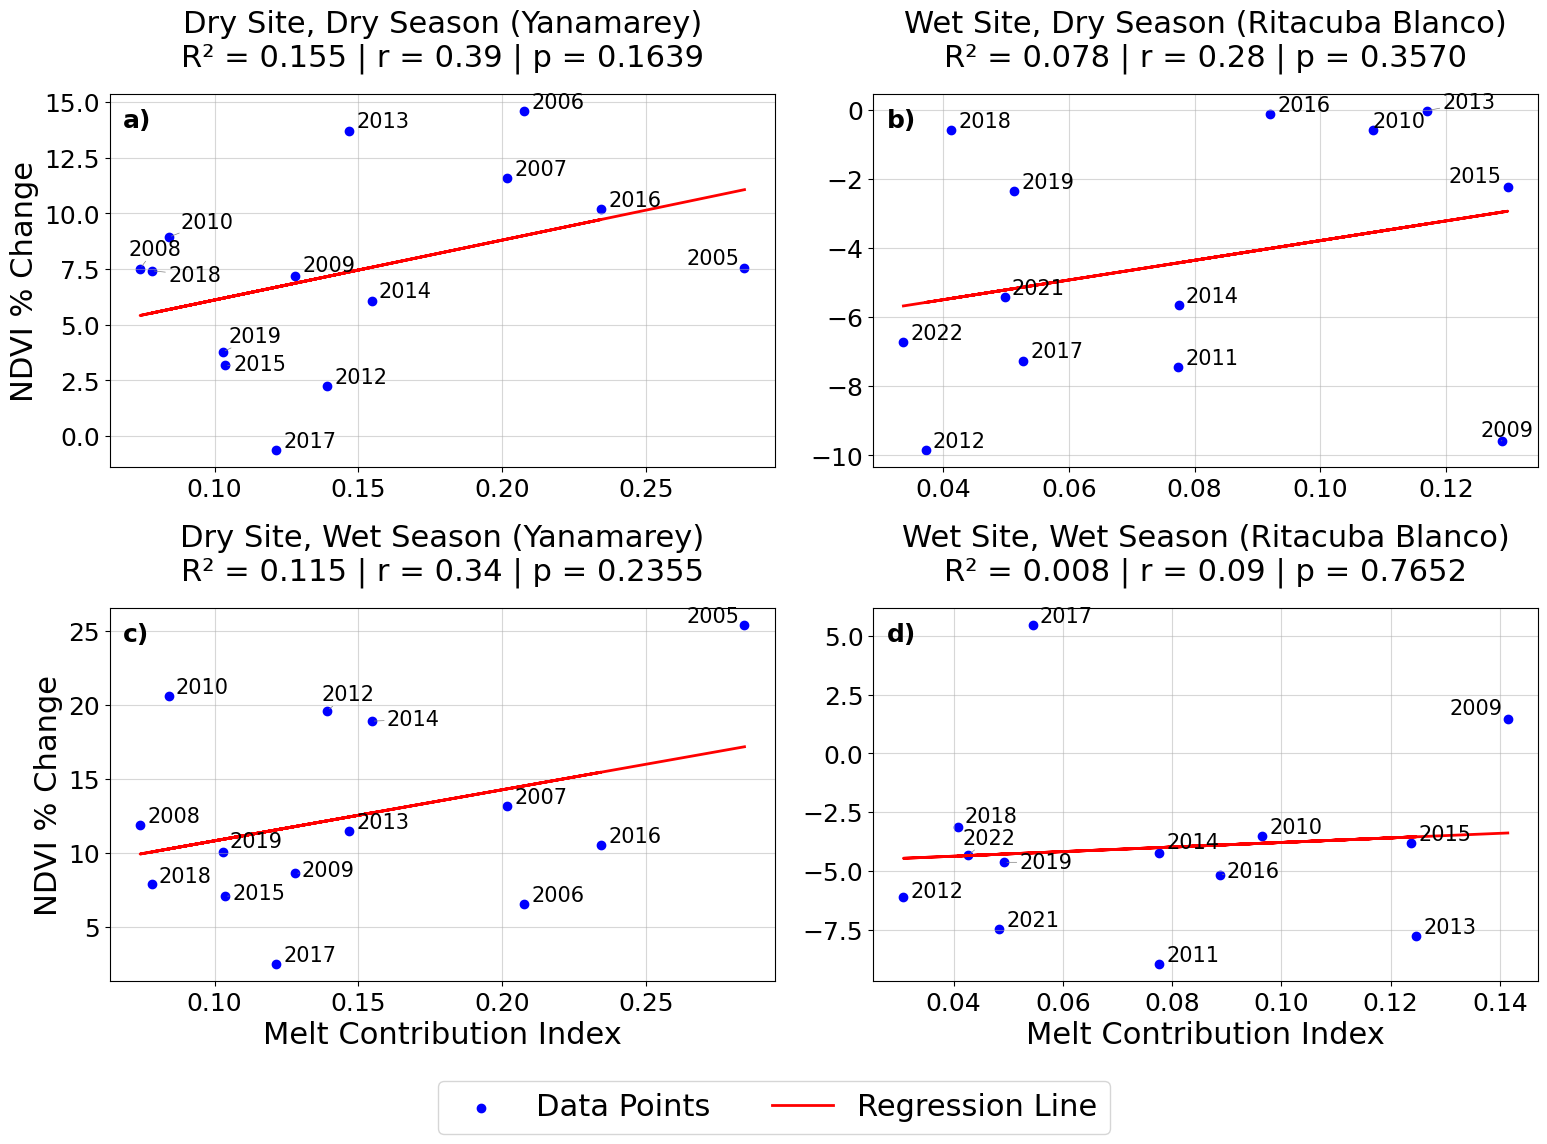

In [25]:
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from pathlib import Path
from adjustText import adjust_text 

# Update global font sizes
plt.rcParams.update({
    'font.size': 24,          # General font size
    'axes.titlesize': 22,     # Subplot title size (a, b, c, d)
    'axes.labelsize': 22,     # X and Y axis labels
    'xtick.labelsize': 18,    # X-axis tick numbers
    'ytick.labelsize': 18,    # Y-axis tick numbers
    'legend.fontsize': 22     # Legend text size
})


# ==========================================
# 1. FILE PATHS & INITIAL SETUP
# ==========================================
BASE = Path("/Users/williamhirsh/Documents/School - Research/GlacierProject")

NDVI_PATHS = {
    "yan": {
        "imp": BASE / "Intermediate/NDVI/YanImpNSmooth.csv",
        "non": BASE / "Intermediate/NDVI/YanNonNSmooth.csv",
    },
    "rb": {
        "imp": BASE / "Intermediate/NDVI/RBImpNSmooth.csv",
        "non": BASE / "Intermediate/NDVI/RBNonNSmooth.csv",
    }
}

CLIMATE_PATHS = {
    "yan": {
        "chirps": BASE / "RawData/Climate/Precipitation/chirps_Yan.csv",
        "mb": BASE / "RawData/MassBalance/MBA_Yanamarey_01.csv",
    },
    "rb": {
        "chirps": BASE / "RawData/Climate/Precipitation/chirps_RB.csv",
        "mb": BASE / "RawData/MassBalance/MBA_Ritacuba_01.csv",
    }
}

MCI_PATHS = {
    "yan": BASE / "Intermediate/MCI/yan_MCI.csv",
    "rb": BASE / "Intermediate/MCI/rb_MCI.csv",
}

SITE_CONFIG = {
    "yan": {
        "wy_start": 10,
        "start_yr": 2000,
        "basin_area_km2": 4.17,
        "title_prefix": "Yanamarey"
    },
    "rb": {
        "wy_start": 1, 
        "start_yr": 1990,
        "basin_area_km2": 5.43, 
        "title_prefix": "Ritacuba Blanco"
    }
}

# ==========================================
# 2. SUBPLOT CONFIGURATIONS
# ==========================================
DRY_SITE = "yan"
WET_SITE = "rb"

PLOT_CONFIGS = [
    {"title": "Dry Site, Dry Season", "site": DRY_SITE, "months": [6, 7, 8], "wy_offset": 0},
    {"title": "Wet Site, Dry Season", "site": WET_SITE, "months": [1, 2, 3], "wy_offset": 1},
    {"title": "Dry Site, Wet Season", "site": DRY_SITE, "months": [2, 3, 4], "wy_offset": 0},
    {"title": "Wet Site, Wet Season", "site": WET_SITE, "months": [9, 10, 11], "wy_offset": 0} 
]

# ==========================================
# 3. HELPER FUNCTIONS
# ==========================================
def average_ndvi_by_month(ndvi_data, months):
    df = ndvi_data.copy()
    df['year'] = pd.to_datetime(df['time']).dt.year
    df['month'] = pd.to_datetime(df['time']).dt.month
    return df[df['month'].isin(months)].groupby('year')['NDVI_smoothed'].mean().reset_index()

def get_plot_data(site, months, wy_offset):
    """Loads and processes data for a specific site and season setup."""
    imp_ndvi = pd.read_csv(NDVI_PATHS[site]["imp"])
    non_ndvi = pd.read_csv(NDVI_PATHS[site]["non"])
    chirps = pd.read_csv(CLIMATE_PATHS[site]["chirps"])
    mb = pd.read_csv(CLIMATE_PATHS[site]["mb"])
    mb_metric = pd.read_csv(MCI_PATHS[site])
    
    cfg = SITE_CONFIG[site]
    wy_month = cfg["wy_start"]
    start_yr = cfg["start_yr"]
    end_yr = 2024
    basin_area_km2 = cfg["basin_area_km2"]

    chirps["date"] = pd.to_datetime(chirps["date"], format="%Y-%m")
    chirps["year"] = chirps["date"].dt.year
    chirps["month"] = chirps["date"].dt.month
    chirps["precipitation"] = chirps["precip_mm"].astype(float)

    # Standard water year logic
    chirps["water_year"] = chirps["year"]
    if wy_month > 1:
        chirps.loc[chirps["month"] >= wy_month, "water_year"] += 1

    chirps_filtered = chirps[(chirps["water_year"] >= start_yr) & (chirps["water_year"] <= end_yr)]
    water_year_precip = chirps_filtered.groupby("water_year")["precipitation"].sum().reset_index()
    water_year_precip.rename(columns={'water_year': 'Year', 'precipitation': 'Precipitation'}, inplace=True)

    # --- APPLY LAG TO PRECIPITATION ---
    # Shifts precipitation forward so last year's precip aligns with current year's NDVI
    water_year_precip['Year'] += wy_offset 

    merged_data = water_year_precip.copy()

    imp_avg_ndvi = average_ndvi_by_month(imp_ndvi, months)
    merged_data = merged_data.merge(imp_avg_ndvi, how='left', left_on='Year', right_on='year')
    merged_data.rename(columns={'NDVI_smoothed': 'Imp_NDVI_Avg'}, inplace=True)

    non_avg_ndvi = average_ndvi_by_month(non_ndvi, months)
    merged_data = merged_data.merge(non_avg_ndvi, how='left', left_on='Year', right_on='year')
    merged_data.rename(columns={'NDVI_smoothed': 'Non_NDVI_Avg'}, inplace=True)

    merged_data["Percent_Change"] = ((merged_data["Imp_NDVI_Avg"] - merged_data["Non_NDVI_Avg"]) / merged_data["Non_NDVI_Avg"]) * 100

    mb["Year"] = mb["Year"].astype(int)
    merged_data = merged_data.merge(mb, on='Year', how='left')
    merged_data["Glacier_Area"] = merged_data["AreaNew"]

    mb_metric["Year"] = mb_metric["Year"].astype(int)
    merged_data = merged_data.merge(mb_metric, on='Year', how='left')

    mm_to_t = 1e3
    # Note: Precip is lagged by wy_offset here, MB is not.
    merged_data["Glacier_Melt_Water_Mass"] = (merged_data["Precipitation"] - merged_data["MB"]) * merged_data["Glacier_Area"] * mm_to_t
    merged_data["Precip_Water_Mass"] = merged_data["Precipitation"] * (basin_area_km2 - merged_data["Glacier_Area"]) * mm_to_t
    merged_data["Combined_Water_Mass"] = merged_data["Precip_Water_Mass"] + merged_data["Glacier_Melt_Water_Mass"]
    merged_data["MeltCont"] = merged_data["Glacier_Melt_Water_Mass"] / merged_data["Combined_Water_Mass"]

    merged_data['Year'] = merged_data['Year'].astype(str)
    
    return merged_data[['Year', 'MeltCont', 'Percent_Change']].dropna()

# ==========================================
# 4. PLOTTING
# ==========================================
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

x_var = 'MeltCont'
y_var = 'Percent_Change'
scatter_handle, line_handle = None, None

for i, config in enumerate(PLOT_CONFIGS):
    ax = axes[i]
    # Pass wy_offset into the function
    df = get_plot_data(config["site"], config["months"], config["wy_offset"])
    
    X_vals = df[x_var].values
    y_vals = df[y_var].values
    X_reshape = X_vals.reshape(-1, 1)
    
    corr, p_value = stats.pearsonr(X_vals, y_vals)
    model = LinearRegression().fit(X_reshape, y_vals)
    y_pred = model.predict(X_reshape)
    r_squared = model.score(X_reshape, y_vals)
    
    scatter = ax.scatter(X_vals, y_vals, color='blue', label='Data Points')
    line, = ax.plot(X_vals, y_pred, color='red', linewidth=2, label='Regression Line')
    
    if i == 0:
        scatter_handle, line_handle = scatter, line
    
    # --- ANTI-OVERLAP TEXT ANNOTATIONS ---
    texts = []
    for idx, row in df.iterrows():
        texts.append(ax.text(row[x_var], row[y_var], str(row['Year']), fontsize=15))
    
    adjust_text(texts, ax=ax, arrowprops=dict(arrowstyle="-", color='gray', lw=0.5))
        
# Only draw the X-axis label on the bottom row (indices 2 and 3)
    if i >= 2:
        ax.set_xlabel('Melt Contribution Index')
        
    # Only draw the Y-axis label on the left column (indices 0 and 2)
    if i % 2 == 0:
        ax.set_ylabel('NDVI % Change')
    ax.grid(True, alpha=0.5)
    
    # --- SUBPLOT LETTER & TITLE FORMATTING ---
    # Generates a), b), c), d) automatically
    subplot_letter = f"{chr(97 + i)})" 
    
    # Bold letter in top left corner
    ax.annotate(subplot_letter, xy=(0.02, 0.96), xycoords='axes fraction', 
                fontweight='bold', fontsize=18, va='top', ha='left')
    
    site_prefix = SITE_CONFIG[config["site"]]["title_prefix"]
    title_str = (f"{config['title']} ({site_prefix})\n"
                 f"R² = {r_squared:.3f} | r = {corr:.2f} | p = {p_value:.4f}")
    ax.set_title(title_str, pad=20)

plt.tight_layout()
# 1. Increase this from 0.1 to 0.15 (or 0.18) to create more empty space at the bottom
fig.subplots_adjust(bottom=0.16) 

# 2. Add bbox_to_anchor to precisely place the legend in that empty space
fig.legend([scatter_handle, line_handle], ['Data Points', 'Regression Line'], 
           loc='lower center', ncol=2, bbox_to_anchor=(0.5, 0.02))

plt.show()

plt.show()

### NDVI Regression

#### Load and set parameters

In [52]:
import pandas as pd
from pathlib import Path


# CHANGE THIS
SITE = "rb"   # "rb" or "yan"


months_to_average_dry = [1,2,3]
months_to_average_wet = [9,10,11]

BASE = Path("/Users/williamhirsh/Documents/School - Research/GlacierProject")


# NDVI paths
NDVI_PATHS = {
    "yan": {
        "imp": BASE / "Intermediate/NDVI/YanImpNSmooth.csv",
        "non": BASE / "Intermediate/NDVI/YanNonNSmooth.csv",
    },
    "rb": {
        #"imp": BASE / "Intermediate/NDVI/RBImpNSmooth.csv",
        #"non": BASE / "Intermediate/NDVI/RBNonNSmooth.csv",
        "imp": BASE / "Intermediate/NDVI/RImpMedSmooth.csv",
        "non": BASE / "Intermediate/NDVI/RNonMedSmooth.csv",
    }
}

imp_ndvi = pd.read_csv(NDVI_PATHS[SITE]["imp"])
non_ndvi = pd.read_csv(NDVI_PATHS[SITE]["non"])

#### Old Merging Data

In [47]:
def average_ndvi_by_month(ndvi_data, months, out_col):
    df = ndvi_data.copy()
    df['year'] = pd.to_datetime(df['time']).dt.year
    df['month'] = pd.to_datetime(df['time']).dt.month
    return (df[df['month'].isin(months)].groupby('year', as_index=False)['NDVI_smoothed'].mean().rename(columns={'NDVI_smoothed': out_col}))

#Impacted - dry
merged_ndvi = average_ndvi_by_month(imp_ndvi, months_to_average_dry, 'Imp_NDVI_Avg_Dry')

# Impacted – wet
imp_wet = average_ndvi_by_month(imp_ndvi, months_to_average_wet, 'Imp_NDVI_Avg_Wet')
merged_ndvi = merged_ndvi.merge(imp_wet, on='year', how='left')

# Non-impacted – dry
non_dry = average_ndvi_by_month(non_ndvi, months_to_average_dry, 'Non_NDVI_Avg_Dry')
merged_ndvi = merged_ndvi.merge(non_dry, on='year', how='left')

# Non-impacted – wet
non_wet = average_ndvi_by_month(non_ndvi, months_to_average_wet, 'Non_NDVI_Avg_Wet')
merged_ndvi = merged_ndvi.merge(non_wet, on='year', how='left')





#### New Merging Data

In [53]:
SHIFT_WET_NDVI_BY_ONE_YEAR = True  # set to False to turn off

def average_ndvi_by_month(ndvi_data, months, out_col, year_shift=0):
    df = ndvi_data.copy()
    df['time'] = pd.to_datetime(df['time'])
    df['year'] = df['time'].dt.year + year_shift
    df['month'] = df['time'].dt.month

    return (
        df[df['month'].isin(months)]
        .groupby('year', as_index=False)['NDVI_smoothed']
        .mean()
        .rename(columns={'NDVI_smoothed': out_col})
    )

# Impacted – dry
merged_ndvi = average_ndvi_by_month(
    imp_ndvi,
    months_to_average_dry,
    'Imp_NDVI_Avg_Dry'
)

# Impacted – wet
imp_wet = average_ndvi_by_month(
    imp_ndvi,
    months_to_average_wet,
    'Imp_NDVI_Avg_Wet',
    year_shift=1 if SHIFT_WET_NDVI_BY_ONE_YEAR else 0
)
merged_ndvi = merged_ndvi.merge(imp_wet, on='year', how='left')

# Non-impacted – dry
non_dry = average_ndvi_by_month(
    non_ndvi,
    months_to_average_dry,
    'Non_NDVI_Avg_Dry'
)
merged_ndvi = merged_ndvi.merge(non_dry, on='year', how='left')

# Non-impacted – wet
non_wet = average_ndvi_by_month(
    non_ndvi,
    months_to_average_wet,
    'Non_NDVI_Avg_Wet',
    year_shift=1 if SHIFT_WET_NDVI_BY_ONE_YEAR else 0
)
merged_ndvi = merged_ndvi.merge(non_wet, on='year', how='left')


In [54]:
merged_ndvi[['year',
             'Imp_NDVI_Avg_Dry',
             'Imp_NDVI_Avg_Wet',
             'Non_NDVI_Avg_Dry',
             'Non_NDVI_Avg_Wet']].head(10)


,year,Imp_NDVI_Avg_Dry,Imp_NDVI_Avg_Wet,Non_NDVI_Avg_Dry,Non_NDVI_Avg_Wet
0,2000,0.401000,NaN,0.366333,NaN
1,2001,0.474833,0.4971,0.469667,0.5316
2,2002,0.457833,0.4728,0.469250,0.5099
3,2003,0.473583,0.5106,0.454917,0.5593
4,2004,0.483167,0.4686,0.461750,0.4868
5,2005,0.499500,0.5155,0.505833,0.5654
6,2006,0.513500,0.5062,0.527250,0.5310
7,2007,0.469333,0.5205,0.495750,0.5686
8,2008,0.488583,0.4998,0.535750,0.5338
9,2009,0.493583,0.4965,0.545917,0.5091


#### Plotting

Dry Season Pearson r: 0.87, p = 0.0000
Dry Season R² = 0.76

Wet Season Pearson r: 0.82, p = 0.0000
Wet Season R² = 0.68



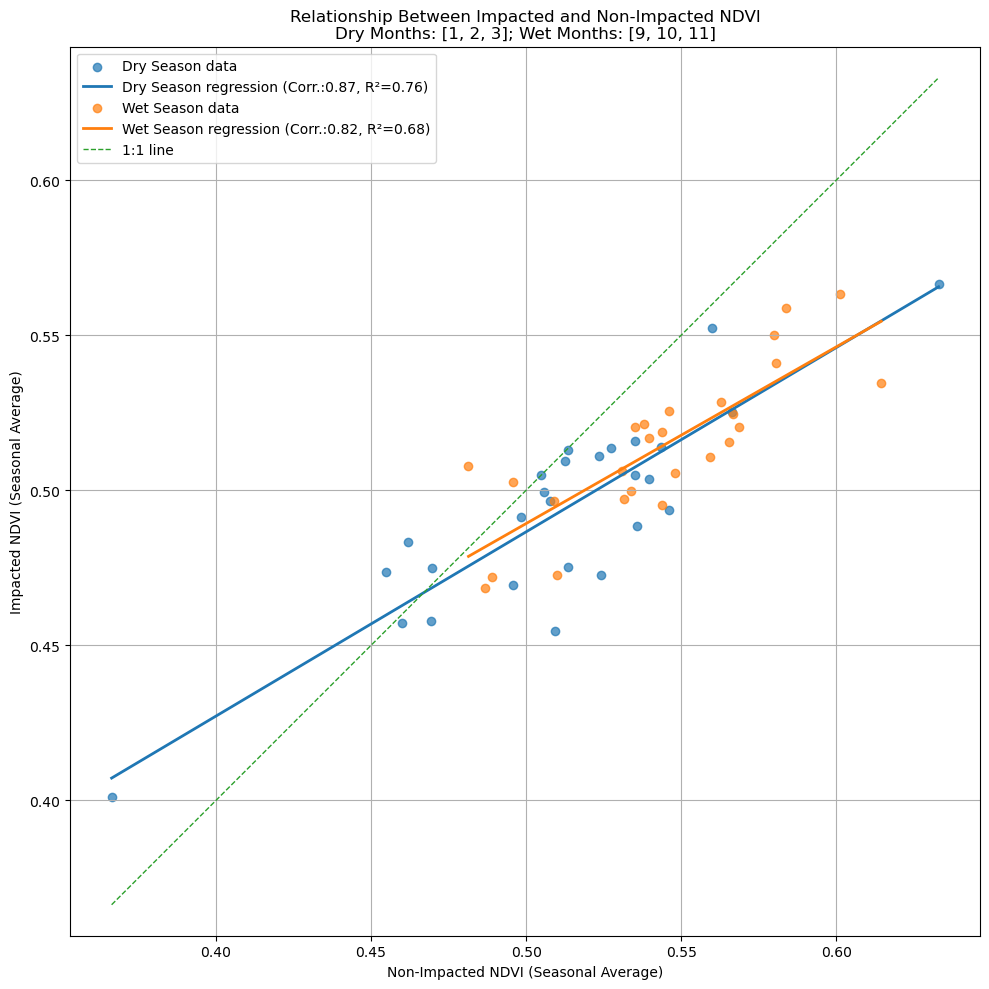

In [55]:
from scipy import stats
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import numpy as np

pairs = [
    ("Non_NDVI_Avg_Dry", "Imp_NDVI_Avg_Dry", "Dry Season"),
    ("Non_NDVI_Avg_Wet", "Imp_NDVI_Avg_Wet", "Wet Season"),
]

plt.figure(figsize=(10,10))

for x_var, y_var, label in pairs:

    # --- FILTER & CLEAN ---
    corr_df = merged_ndvi[[x_var, y_var, "year"]].dropna()

    # --- CORRELATION ---
    corr, p_value = stats.pearsonr(corr_df[x_var], corr_df[y_var])
    print(f"{label} Pearson r: {corr:.2f}, p = {p_value:.4f}")

    # --- REGRESSION ---
    X = corr_df[x_var].values.reshape(-1, 1)
    y = corr_df[y_var].values

    model = LinearRegression()
    model.fit(X, y)
    y_pred = model.predict(X)

    r_squared = model.score(X, y)
    print(f"{label} R² = {r_squared:.2f}\n")

    # Sort for clean regression line
    sort_idx = np.argsort(corr_df[x_var].values)

    # --- PLOTTING ---
    plt.scatter(
        corr_df[x_var],
        corr_df[y_var],
        alpha=0.7,
        label=f"{label} data"
    )

    plt.plot(
        corr_df[x_var].values[sort_idx],
        y_pred[sort_idx],
        linewidth=2,
        label=f"{label} regression (Corr.:{corr:.2f}, R²={r_squared:.2f})"
    )

# Collect all x and y values used in the plot
all_vals = []

for x_var, y_var, _ in pairs:
    vals = merged_ndvi[[x_var, y_var]].values.flatten()
    all_vals.extend(vals[~np.isnan(vals)])

vmin = min(all_vals)
vmax = max(all_vals)

#Plot 1=1
plt.plot(
    [vmin, vmax],
    [vmin, vmax],
    linestyle="--",
    linewidth=1,
    label="1:1 line"
)


# --- AXES, TITLE, LEGEND ---
plt.xlabel("Non-Impacted NDVI (Seasonal Average)")
plt.ylabel("Impacted NDVI (Seasonal Average)")
plt.title(f"Relationship Between Impacted and Non-Impacted NDVI\nDry Months: {str(months_to_average_dry)}; Wet Months: {str(months_to_average_wet)}")
plt.legend()
plt.grid(True)





plt.tight_layout()



plt.axis("equal")


plt.show()


### One-plot plotting

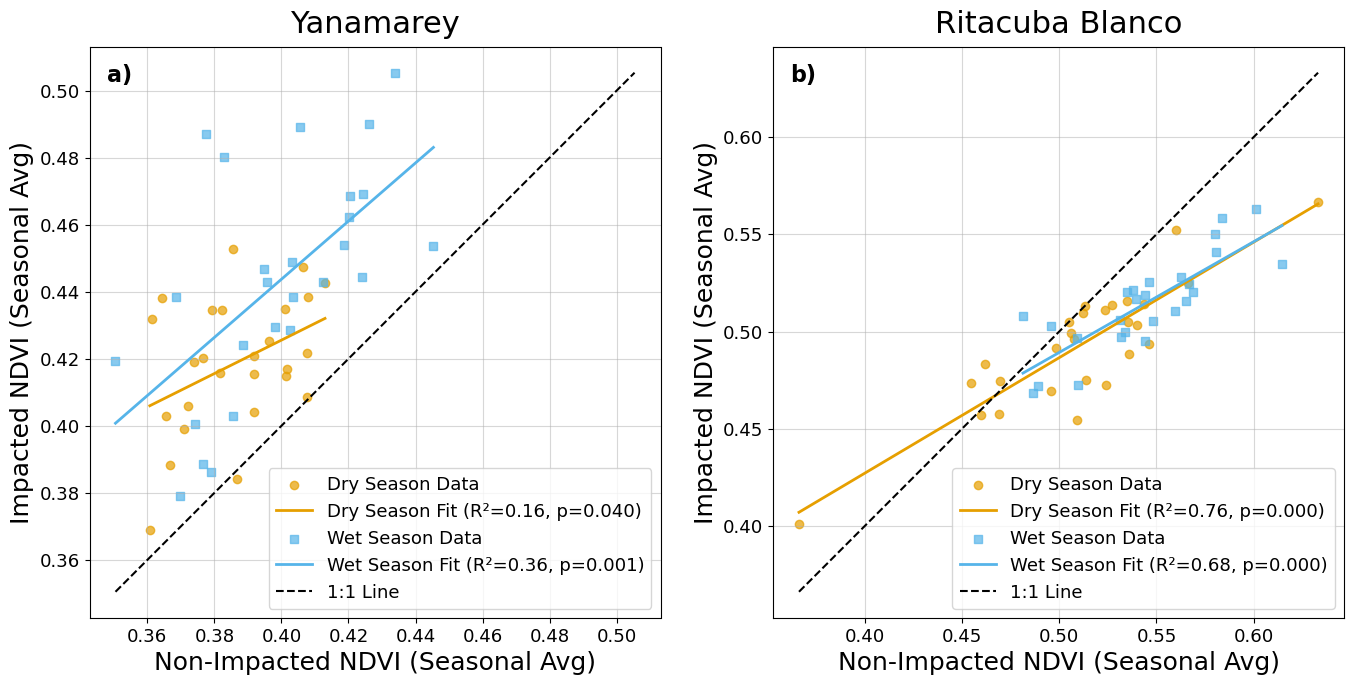

In [32]:
import pandas as pd
import numpy as np
from pathlib import Path
from scipy import stats
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

# ==========================================
# 1. GLOBAL SETTINGS & PATHS
# ==========================================
plt.rcParams.update({
    'font.size': 22,
    'axes.titlesize': 22,
    'axes.labelsize': 18,
    'xtick.labelsize': 13,
    'ytick.labelsize': 13,
    'legend.fontsize': 13
})

BASE = Path("/Users/williamhirsh/Documents/School - Research/GlacierProject")

NDVI_PATHS = {
    "yan": {
        "imp": BASE / "Intermediate/NDVI/YanImpNSmooth.csv",
        "non": BASE / "Intermediate/NDVI/YanNonNSmooth.csv",
    },
    "rb": {
        "imp": BASE / "Intermediate/NDVI/RImpMedSmooth.csv",
        "non": BASE / "Intermediate/NDVI/RNonMedSmooth.csv",
    }
}

# ==========================================
# 2. SITE & SEASON CONFIGURATIONS
# ==========================================
SITE_CONFIGS = [
    {
        "site": "yan",
        "title": "Yanamarey",
        "seasons": [
            {"label": "Dry Season", "months": [6, 7, 8], "year_shift": 0, "color": "#E69F00", "marker": "o"},
            {"label": "Wet Season", "months": [2, 3, 4], "year_shift": 0, "color": "#56B4E9", "marker": "s"}
        ]
    },
    {
        "site": "rb",
        "title": "Ritacuba Blanco",
        "seasons": [
            {"label": "Dry Season", "months": [1, 2, 3], "year_shift": 0, "color": "#E69F00", "marker": "o"},
            {"label": "Wet Season", "months": [9, 10, 11], "year_shift": 1, "color": "#56B4E9", "marker": "s"}
        ]
    }
]

# ==========================================
# 3. HELPER FUNCTION
# ==========================================
def get_ndvi_scatter_data(site, months, year_shift):
    imp_ndvi = pd.read_csv(NDVI_PATHS[site]["imp"])
    non_ndvi = pd.read_csv(NDVI_PATHS[site]["non"])
    
    def process_ndvi(df, name):
        d = df.copy()
        d['time'] = pd.to_datetime(d['time'])
        d['year'] = d['time'].dt.year + year_shift
        d['month'] = d['time'].dt.month
        
        return (d[d['month'].isin(months)]
                .groupby('year', as_index=False)['NDVI_smoothed']
                .mean()
                .rename(columns={'NDVI_smoothed': name}))

    imp_avg = process_ndvi(imp_ndvi, 'Imp_NDVI')
    non_avg = process_ndvi(non_ndvi, 'Non_NDVI')
    
    return imp_avg.merge(non_avg, on='year', how='outer').dropna()

# ==========================================
# 4. PLOTTING SETUP
# ==========================================
# Removed sharex=True and sharey=True so each plot scales independently
fig, axes = plt.subplots(1, 2, figsize=(14, 7))

# ==========================================
# 5. PLOTTING LOOP
# ==========================================
for i, config in enumerate(SITE_CONFIGS):
    ax = axes[i]
    
    # We will collect all values for this specific site to calculate its own 1:1 line
    site_vals = []
    
    for season in config["seasons"]:
        df = get_ndvi_scatter_data(config["site"], season["months"], season["year_shift"])
        
        x_vals = df['Non_NDVI'].values
        y_vals = df['Imp_NDVI'].values
        
        # Store values for the local 1:1 line calculation
        site_vals.extend(x_vals)
        site_vals.extend(y_vals)
        
        # Correlation & Regression
        corr, p_value = stats.pearsonr(x_vals, y_vals)
        X_reshape = x_vals.reshape(-1, 1)
        model = LinearRegression().fit(X_reshape, y_vals)
        y_pred = model.predict(X_reshape)
        r_squared = model.score(X_reshape, y_vals)

        sort_idx = np.argsort(x_vals)

        # Plotting elements
        c = season["color"]
        m = season["marker"]
        l = season["label"]
        line_label = f"{l} Fit (R²={r_squared:.2f}, p={p_value:.3f})"

        ax.scatter(x_vals, y_vals, alpha=0.7, color=c, marker=m, label=f"{l} Data")
        ax.plot(x_vals[sort_idx], y_pred[sort_idx], linewidth=2, color=c, label=line_label)
    
    # --- Local 1:1 Line ---
    # Calculate min and max strictly for the current subplot
    vmin, vmax = min(site_vals), max(site_vals)
    ax.plot([vmin, vmax], [vmin, vmax], linestyle="--", linewidth=1.5, color='black', label="1:1 Line")

    # --- Formatting ---
    subplot_letter = f"{chr(97 + i)})" 
    ax.annotate(subplot_letter, xy=(0.03, 0.97), xycoords='axes fraction', 
                fontweight='bold', fontsize=16, va='top', ha='left')

    ax.set_title(config["title"], pad=10)

    # Force square aspect ratio based on local limits
    ax.set_aspect('equal', 'box')
    ax.grid(True, alpha=0.5)
    ax.legend(loc='lower right')

    # Add axis labels to both plots since they no longer share scales
    ax.set_xlabel("Non-Impacted NDVI (Seasonal Avg)")
    ax.set_ylabel("Impacted NDVI (Seasonal Avg)")

plt.tight_layout()
plt.show()